# PyMolFit 03: A broad echelle spectrum

This tutorial corrects a broad, stitched HARPS Phase 3 spectrum with 313,090 samples. PyMolFit automatically divides the radiative-transfer calculation into bounded wavelength segments, fits shared atmospheric and instrumental parameters from predetermined H2O and O2 windows, and stitches the corrected segments back onto the original monotonic axis.

This file is an extracted and merged one-dimensional product, not a raw two-dimensional echellogram. Raw extraction, blaze correction, order merging, and wavelength calibration must occur before PyMolFit.

In [1]:
%matplotlib widget

%matplotlib widget

from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from pymolfit import correct_file, load_spectrum

candidates = (Path.cwd() / "tutorials", Path.cwd())
TUTORIAL_ROOT = next((p.resolve() for p in candidates if (p / "data").is_dir()), None)
if TUTORIAL_ROOT is None:
    raise FileNotFoundError("Could not locate tutorials/data")
INPUT = TUTORIAL_ROOT / "data" / "ADP.2017-04-07T01_04_41.632.fits"
OUTPUT = TUTORIAL_ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)
print("Input size [MiB]:", INPUT.stat().st_size / 2**20)

Input size [MiB]: 5.020751953125


## Inspect the FITS structure and wavelength scale

The primary header carries observation metadata. The `SPECTRUM` binary table contains vector columns named `WAVE`, `FLUX`, and `ERR`. PyMolFit flattens this common Phase 3 representation into a generic one-dimensional `Spectrum`.

In [2]:
with fits.open(INPUT, memmap=True) as hdul:
    print("HDU structure:")
    for index, hdu in enumerate(hdul):
        shape = None if hdu.data is None else hdu.data.shape
        print(f"{index}: {hdu.name}, {type(hdu).__name__}, shape={shape}")
    header = hdul[0].header
    print({key: header.get(key) for key in ("OBJECT", "INSTRUME", "DATE-OBS", "SPECSYS")})

spectrum = load_spectrum(INPUT, wavelength_medium="air").to_air().to_unit("angstrom")
print("Samples:", spectrum.wavelength.size)
print("Range [Angstrom]:", spectrum.wavelength[[0, -1]])
print("Median spacing [Angstrom]:", np.nanmedian(np.diff(spectrum.wavelength)))

HDU structure:
0: PRIMARY, PrimaryHDU, shape=None
1: SPECTRUM, BinTableHDU, shape=(1,)
{'OBJECT': 'Beta_Pic', 'INSTRUME': 'HARPS', 'DATE-OBS': '2017-04-06T00:05:02.828', 'SPECSYS': 'BARYCENT'}
Samples: 313090
Range [Angstrom]: [3781.75 6912.64]
Median spacing [Angstrom]: 0.010000000000218279


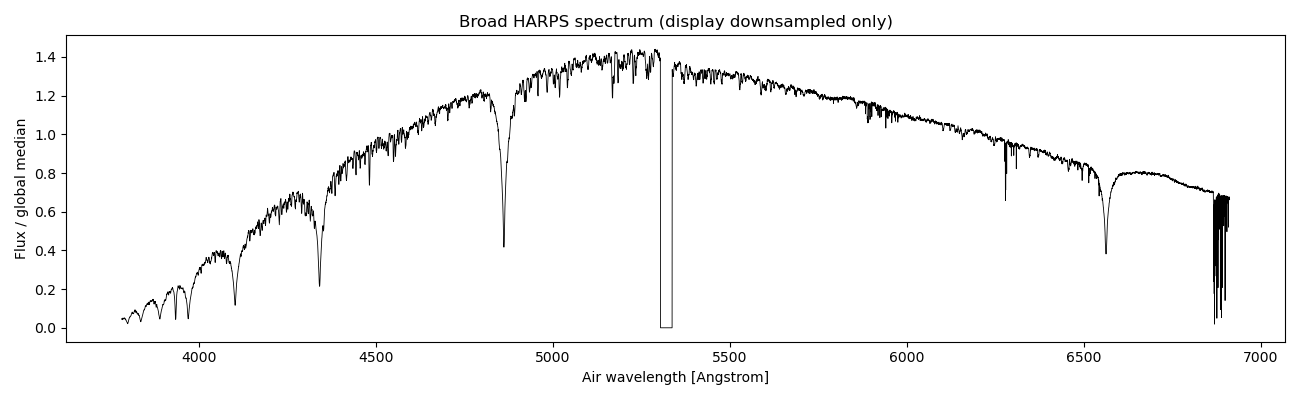

In [3]:
stride = 40
valid_flux = spectrum.flux[spectrum.valid]
scale = np.nanmedian(valid_flux)

plt.figure(figsize=(13, 4))
plt.plot(spectrum.wavelength[::stride], spectrum.flux[::stride] / scale, color="black", linewidth=0.6)
plt.xlabel("Air wavelength [Angstrom]")
plt.ylabel("Flux / global median")
plt.title("Broad HARPS spectrum (display downsampled only)")
plt.tight_layout()
plt.show()

## Choose information-bearing fit windows

Automatic segmentation solves the memory problem; it does not decide which pixels are safe for atmospheric inference. This example uses a water-vapour-sensitive window near Na D and the established O2 B band. The broad astrophysical Na D lines are excluded.

Only species constrained by the selected windows should be interpreted. Correcting every possible atmospheric species across a broad spectrum requires fit windows that contain measurable lines for each desired species.

In [4]:
FIT_RANGES = (
    (0.58825, 0.59065),  # H2O lines around Na D
    (0.6868, 0.6905),    # O2 B band
)
EXCLUDE_RANGES = (
    (0.58888, 0.58934),  # Stellar/circumstellar Na D2
    (0.58936, 0.58993),  # Stellar/circumstellar Na D1
)
for lower, upper in FIT_RANGES:
    print(f"Fit window: {lower * 1e4:.1f}-{upper * 1e4:.1f} Angstrom")

Fit window: 5882.5-5906.5 Angstrom
Fit window: 6868.0-6905.0 Angstrom


## Run the segmented fit

`segment_size=0.01` means a maximum nominal width of 0.01 micron (100 Angstrom). PyMolFit may subdivide further if its high-resolution radiative-transfer grid would exceed the safety limit. Molecular scales and fitted LSF parameters are shared; each segment receives its own local continuum.

HARPS has approximately constant wavelength sampling in this product. `lsf_variable_width=True` therefore lets the Gaussian pixel width scale with wavelength, as expected for roughly constant resolving power. This cell can take about one minute on a laptop after the AER catalogue is cached.

In [5]:
started = time.perf_counter()
result = correct_file(
    input_path=INPUT,
    output_path=OUTPUT / "03_harps_broad_corrected.ecsv",
    product_path=OUTPUT / "03_harps_broad_fit_product.ecsv",
    wavelength_medium="air",
    aer_catalog="auto",
    atmosphere_mode="mipas_gdas",
    gdas_mode="average",
    auto_segment=True,
    segment_size=0.01,
    continuum_order=2,
    solve_continuum_linear=True,
    lsf_box_width_pixels=1.0,
    lsf_sigma_pixels=2.17,
    fit_lsf_sigma=True,
    lsf_sigma_bounds=(0.5, 4.0),
    lsf_lorentz_fwhm_pixels=0.5,
    fit_lsf_lorentz_fwhm=True,
    lsf_lorentz_fwhm_bounds=(0.0, 6.0),
    lsf_variable_width=True,
    lsf_reference_wavelength_micron=0.589,
    fit_wavelength_shift=True,
    wavelength_shift_bounds=(-2e-5, 2e-5),
    fit_ranges=FIT_RANGES,
    exclude_ranges=EXCLUDE_RANGES,
)
elapsed = time.perf_counter() - started
print(f"Elapsed: {elapsed:.1f} s")

Elapsed: 65.3 s


## Verify the stitched result

The returned object has the same high-level interface as a narrow fit. Segmentation details are retained in the spectrum metadata, optimizer message, per-pixel fit mask, and product provenance. Pixels outside the fit windows receive the shared fitted transmission but do not influence the optimized parameters.

In [6]:
print("Success:", result.success)
print("Message:", result.message)
print("Output samples:", result.corrected.wavelength.size)
print("Automatic segmentation:", result.corrected.meta.get("automatic_segmentation"))
print("Segment count:", result.corrected.meta.get("segment_count"))
print("Requested segment size [micron]:", result.corrected.meta.get("segment_size_micron"))
print("Pixels used by optimizer:", np.count_nonzero(result.fit_mask))
print("Species scales:", result.species_scales)
print("Parameters at bounds:", result.parameter_bound_status or "none")

Success: True
Message: `ftol` termination condition is satisfied. (automatic segmentation: 32 segments)
Output samples: 313090
Automatic segmentation: True
Segment count: 32
Requested segment size [micron]: 0.01
Pixels used by optimizer: 5070
Species scales: {'CO': 1.0, 'H2O': 0.5732470090683163, 'O2': 0.9900238721222336}
Parameters at bounds: none


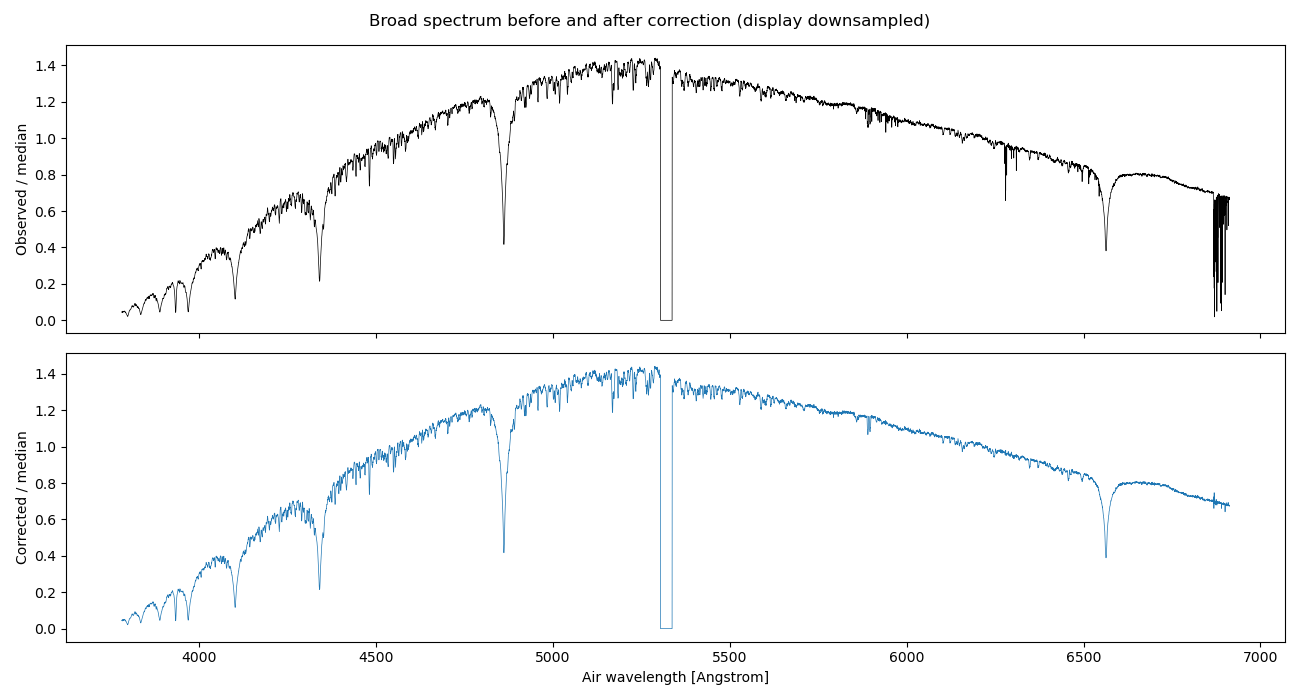

In [7]:
observed = result.spectrum.to_air().to_unit("angstrom")
corrected = result.corrected.to_air().to_unit("angstrom")
scale = np.nanmedian(observed.flux[observed.valid])

figure, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(observed.wavelength[::stride], observed.flux[::stride] / scale, color="black", linewidth=0.5)
axes[0].set_ylabel("Observed / median")
axes[1].plot(corrected.wavelength[::stride], corrected.flux[::stride] / scale, color="tab:blue", linewidth=0.5)
axes[1].set_ylabel("Corrected / median")
axes[1].set_xlabel("Air wavelength [Angstrom]")
figure.suptitle("Broad spectrum before and after correction (display downsampled)")
figure.tight_layout()
plt.show()

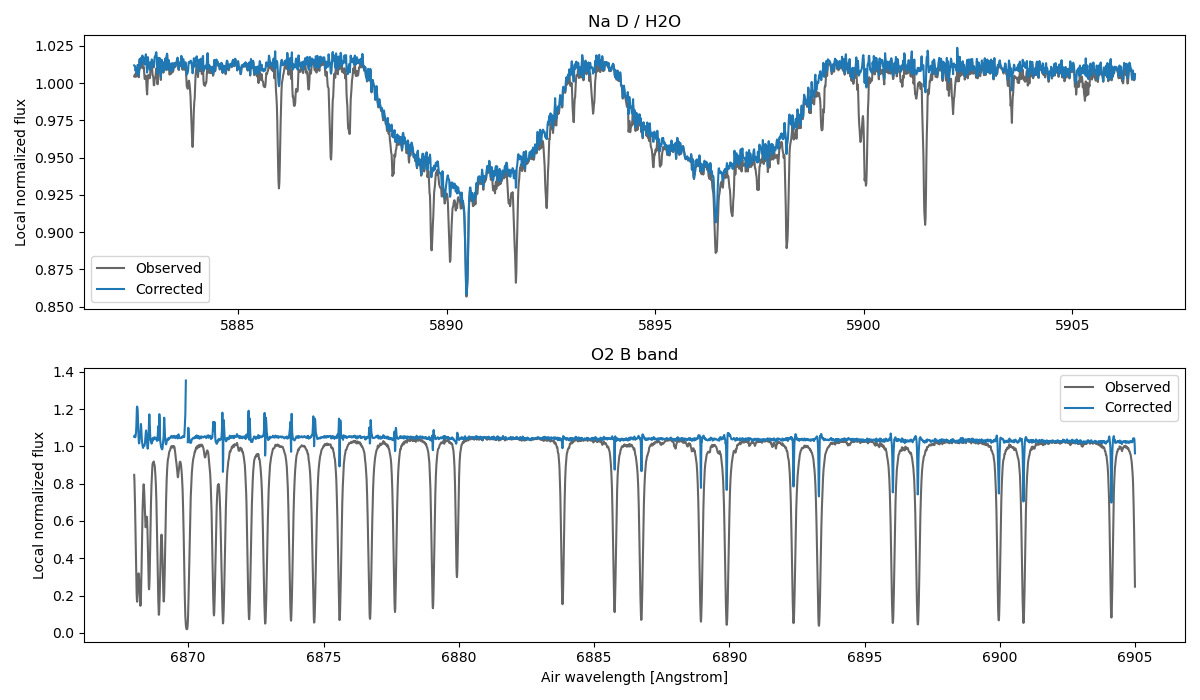

In [8]:
figure, axes = plt.subplots(2, 1, figsize=(12, 7))
for axis, (lower, upper), label in zip(axes, FIT_RANGES, ("Na D / H2O", "O2 B band"), strict=True):
    keep = (observed.wavelength >= lower * 1e4) & (observed.wavelength <= upper * 1e4)
    local_scale = np.nanmedian(observed.flux[keep])
    axis.plot(observed.wavelength[keep], observed.flux[keep] / local_scale, color="black", alpha=0.6, label="Observed")
    axis.plot(corrected.wavelength[keep], corrected.flux[keep] / local_scale, color="tab:blue", label="Corrected")
    axis.set_ylabel("Local normalized flux")
    axis.set_title(label)
    axis.legend()
axes[-1].set_xlabel("Air wavelength [Angstrom]")
figure.tight_layout()
plt.show()

## Native echelle orders

If an instrument stores separate extracted orders, do not merge overlapping orders solely for PyMolFit. Load each order as a `Spectrum` and either:

- call `correct_file` separately when every order can be fitted independently, or
- use `fit_telluric_segments` when several orders should share molecular columns and instrumental parameters.

Order-specific blaze functions belong in the continuum model, while genuine discontinuities or different detector resolutions may require separate fit groups. Do not assume one Gaussian width is valid for every arm, detector, or observing setup.

## Scientific limitation

A full-length output is not evidence that every wavelength was equally validated. Here H2O and O2 are constrained by two predetermined windows. A publication analysis should define and report all fit windows, masks, fitted species, atmosphere source, LSF family, parameter bounds, and rejected/saturated pixels.